### Model selection

In [2]:
import sys
sys.path.append('..')
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
from pathlib import Path

results = pd.read_excel(Path().cwd().parent / 'model_results.xlsx')
results.sort_values('cv_test_lift', ascending=False)

,model_name,model_type,cv_test_lift,cv_train_lift,test_lift,train_lift,cv_test_rmse_logloss,cv_train_rmse_logloss,test_rmse_logloss,train_rmse_logloss,cv_test_r2_auc,cv_train_r2_auc,test_r2_auc,train_r2_auc
1,LightGBMRegressor,regression,1.8024,2.0624,1.7361,NaN,4971.0000,4774.0000,4925.0000,4892.0000,0.1227,0.1907,0.11740,0.1504
0,XGBoostRegressor,regression,1.7840,1.8966,1.7214,NaN,4988.0000,4897.0000,4948.0000,4952.0000,0.1164,0.1484,0.10940,0.1291
2,DecisionTreeRegressor,regression,1.6425,1.6510,1.5882,1.6473,5082.0000,5067.0000,5026.0000,5073.0000,0.0830,0.0884,0.08100,0.0863
3,PLS,regression,1.6218,1.6264,1.5867,1.6254,5160.0000,5158.0000,5098.0000,5158.0000,0.0544,0.0553,0.05430,0.0552
4,ElasticNet,regression,1.6204,1.6250,1.5855,1.6252,5160.0000,5157.0000,5098.0000,5157.0000,0.0547,0.0556,0.05454,0.0556
5,LightGBMClassifier,classification,1.5610,1.7588,1.5063,1.7390,0.4436,0.4224,0.4434,0.4247,0.7348,0.7742,0.73580,0.7697
6,DeepDecisionTreeClassifier,classification,1.3490,1.4679,1.3302,1.4588,0.4749,0.4559,0.4701,0.4574,0.6890,0.7071,0.68920,0.7047
7,ShallowDecisionTreeClassifier,classification,1.2492,1.2537,1.2160,1.2553,0.4698,0.4692,0.4702,0.4693,0.6766,0.6781,0.67640,0.6782


Not surpisingly, the best models are boostsed regressors. LighGBM has the best lift. Compared to XGBoostRegressor, it is more efficient, using leaf-tree growth for more refined splits. Decision tree regressor is third giving an interpretable simple model, but loosing quite a bit of lift. Linear models are marginally worse. Classification models are the worst. There is little reason to use weaker models since increases in lift result in a bigger monetary return than compute cost, so we will use LightGBM regressor

### Model training and saving
Now we train the model on whole available data using previously discovered hyperparameters

In [9]:
from src.data_load import load_data
from src.columns import FEATURE_COLS_CLEAN, REG_TARGET
df = load_data()
df = df[df.issue_d < '2018-01-01']
X = df[FEATURE_COLS_CLEAN]
y = df[REG_TARGET[0]]

In [78]:
import lightgbm as lgb

from src.metrics import lift_score

params = {
    'colsample_bytree': 0.51,
    'max_depth': 15,
    'min_child_samples': 1750,
    'min_child_weight': 1,
    'num_leaves': 180,
    'reg_alpha': 0.04,
    'reg_lambda': 0.25,
    'subsample': 0.89,
}

lgb_model = lgb.LGBMRegressor(
    **params,
    metric='rmse',
    n_estimators=600,
    learning_rate=0.01
)

lgb_model.fit(X, y)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.290387 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9710
[LightGBM] [Info] Number of data points in the train set: 1291750, number of used features: 84
[LightGBM] [Info] Start training from score 490.967682
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

LGBMRegressor(colsample_bytree=0.51, learning_rate=0.01, max_depth=15,
              metric='rmse', min_child_samples=1750, min_child_weight=1,
              n_estimators=600, num_leaves=180, reg_alpha=0.04, reg_lambda=0.25,
              subsample=0.89)

In [93]:
lgb_model.booster_.save_model(Path.cwd().parent / 'model.lgbm')

### Model testing
Now we load the saved model and try to use it for prediction. We use LoanInput object to save and convert raw variables into model-ready data.

In [4]:
from src.loan_input import LoanInput
df_raw = pd.read_csv(Path().cwd().parent / 'data' /'accepted.csv.gz', nrows=10000)
df_raw.head(10)

C:\Users\User\AppData\Local\Temp\ipykernel_29216\374930335.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(Path().cwd().parent / 'data' /'accepted.csv.gz', nrows=10000)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
6,68476668,NaN,20000.0,20000.0,20000.0,36 months,9.17,637.58,B,B2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
7,67275481,NaN,20000.0,20000.0,20000.0,36 months,8.49,631.26,B,B1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
8,68466926,NaN,10000.0,10000.0,10000.0,36 months,6.49,306.45,A,A2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9,68616873,NaN,8000.0,8000.0,8000.0,36 months,11.48,263.74,B,B5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
row = df_raw.iloc[0].to_dict()
loan = LoanInput(**row)
loan

LoanInput(loan_amnt=3600.0, term=36, emp_title='leadman', emp_length=10, home_ownership='MORTGAGE', annual_inc=55000.0, verification_status=0, issue_d=datetime.date(2015, 12, 1), purpose='debt_consolidation', zip_code='190xx', addr_state='PA', dti=5.91, delinq_2yrs=0.0, earliest_cr_line=datetime.date(2003, 8, 1), fico_range_low=675.0, fico_range_high=679.0, inq_last_6mths=1.0, mths_since_last_delinq=30.0, mths_since_last_record=nan, open_acc=7.0, pub_rec=0.0, revol_bal=2765.0, revol_util=29.7, total_acc=13.0, collections_12_mths_ex_med=0.0, mths_since_last_major_derog=30.0, application_type=1, annual_inc_joint=nan, dti_joint=nan, verification_status_joint=0, acc_now_delinq=0.0, tot_coll_amt=722.0, tot_cur_bal=144904.0, open_acc_6m=2.0, open_act_il=2.0, open_il_12m=0.0, open_il_24m=1.0, mths_since_rcnt_il=21.0, total_bal_il=4981.0, il_util=36.0, open_rv_12m=3.0, open_rv_24m=3.0, max_bal_bc=722.0, all_util=34.0, total_rev_hi_lim=9300.0, inq_fi=3.0, total_cu_tl=1.0, inq_last_12m=4.0, acc_

In [7]:
loan_df = loan.to_df()
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 85 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   loan_amnt                       1 non-null      float64 
 1   term                            1 non-null      int64   
 2   emp_title                       1 non-null      category
 3   emp_length                      1 non-null      int64   
 4   home_ownership                  1 non-null      category
 5   annual_inc                      1 non-null      float64 
 6   is_verified                     1 non-null      int64   
 7   issue_y                         1 non-null      int64   
 8   issue_m                         1 non-null      int64   
 9   purpose                         1 non-null      category
 10  zip_code                        1 non-null      category
 11  zip_region                      1 non-null      category
 12  addr_state                

In [8]:
import lightgbm as lgb
model = lgb.Booster(model_file=Path().cwd().parent / "model.lgbm")
model.predict(loan_df)

array([384.78591933])

### Creating public interface
Values, returned by the regression model are not exactly expected returns, but some measure of risk incorporating the information about the actual returns. This way it is able to create better ordering of loans compared to classification models, but the numerical value is not exactly bounded by the nature of the loan: we can easily see expected return of -1000 for a loan of $10, which is not possible. A great way to report the degree of confidence in a decision is to report the percentile value associated with the distribution of loan predictions from -100% to 100%. This way the users are able to quickly understand the degree of distance from the threshold.

We will use LoanPredictor object to create those predictions. We will need to save the threshold and percentiles bins for it to use and return the decision and degree of confidence.

In [10]:
predictions = model.predict(X)

Threshold: -75.4010
Lift: 1.9034 times
Net improvement: $1.207141e+09 - $6.342075e+08 = $5.729338e+08


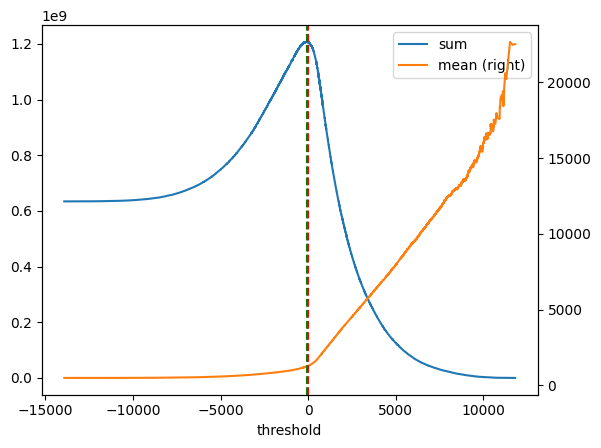

In [ ]:
from src.metrics import plot_curve, build_curve
curve = build_curve(y, predictions)
plot_curve(curve)

In [ ]:
import numpy as np
from src.metrics import curve_threshold
threshold = curve_threshold(curve)
shifted = predictions - threshold
percentiles = np.percentile(shifted, np.arange(0, 101, 1))
print(percentiles)
np.save(Path.cwd().parent / 'bins.npy', percentiles)

[-13839.11100302  -4717.37563672  -3628.54600608  -2987.82418032
  -2537.81335159  -2182.28079537  -1892.34537928  -1647.20026696
  -1437.5421089   -1255.06675496  -1094.23392705   -953.38076153
   -833.54051663   -728.76146612   -635.73426578   -551.63158755
   -477.43955537   -410.50077971   -349.00203138   -292.86492137
   -241.31975961   -192.62522481   -147.08161549   -103.13603296
    -61.85142652    -22.5183569      14.98271699     50.72595639
     84.72479203    117.78005854    149.69841683    179.81904601
    208.80394213    236.96920242    263.28333799    288.37307766
    312.62495374    336.28104024    359.07397225    380.9192702
    402.13094289    422.82468227    442.85665923    462.51719602
    482.13098205    500.93053593    519.30771014    538.11480515
    556.81678745    575.24324563    593.54726183    611.97849472
    630.26633491    649.25698316    668.4854386     687.78251368
    707.68186876    727.75280264    747.90829438    768.82376226
    790.38579484    812.68

### Prediction service testing

In [16]:
print(loan.model_dump_json(indent=4))

{
    "loan_amnt": 3600.0,
    "term": 36,
    "emp_title": "leadman",
    "emp_length": 10,
    "home_ownership": "MORTGAGE",
    "annual_inc": 55000.0,
    "verification_status": 0,
    "issue_d": "2015-12-01",
    "purpose": "debt_consolidation",
    "zip_code": "190xx",
    "addr_state": "PA",
    "dti": 5.91,
    "delinq_2yrs": 0.0,
    "earliest_cr_line": "2003-08-01",
    "fico_range_low": 675.0,
    "fico_range_high": 679.0,
    "inq_last_6mths": 1.0,
    "mths_since_last_delinq": 30.0,
    "mths_since_last_record": null,
    "open_acc": 7.0,
    "pub_rec": 0.0,
    "revol_bal": 2765.0,
    "revol_util": 29.7,
    "total_acc": 13.0,
    "collections_12_mths_ex_med": 0.0,
    "mths_since_last_major_derog": 30.0,
    "application_type": 1,
    "annual_inc_joint": null,
    "dti_joint": null,
    "verification_status_joint": 0,
    "acc_now_delinq": 0.0,
    "tot_coll_amt": 722.0,
    "tot_cur_bal": 144904.0,
    "open_acc_6m": 2.0,
    "open_act_il": 2.0,
    "open_il_12m": 0.0,


### Example data for demo web app
Here we prepare example data to be saved in web app database with necessary data types and formats

In [60]:
mask = df_raw.loan_status.isin(['Fully Paid', 'Charged Off']) & (df_raw.application_type == 'Individual')
sample = df_raw[mask].groupby('loan_status').sample(3)

In [69]:
sample.iloc[:, 10:50].T

,9362,811,4316,6900,9282,1051
emp_title,Store Manager,Teacher,DIETARY DIRECTOR,Fire Engineer,business sales engineer,Senior Substation Operator
emp_length,< 1 year,2 years,7 years,2 years,4 years,6 years
home_ownership,MORTGAGE,MORTGAGE,RENT,RENT,MORTGAGE,MORTGAGE
annual_inc,85000.0,43500.0,42000.0,110000.0,45000.0,107901.0
verification_status,Source Verified,Source Verified,Verified,Source Verified,Not Verified,Source Verified
issue_d,Dec-2015,Dec-2015,Dec-2015,Dec-2015,Dec-2015,Dec-2015
loan_status,Charged Off,Charged Off,Charged Off,Fully Paid,Fully Paid,Fully Paid
pymnt_plan,n,n,n,n,n,n
url,https://lendingclub.com/browse/loanDetail.acti...,https://lendingclub.com/browse/loanDetail.acti...,https://lendingclub.com/browse/loanDetail.acti...,https://lendingclub.com/browse/loanDetail.acti...,https://lendingclub.com/browse/loanDetail.acti...,https://lendingclub.com/browse/loanDetail.acti...
desc,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
sample['name'] = ['Tom Washington', 'George Linkoln', 'Anna Obama', 'Michael Jackson', 'Freddie Aurumie', 'Barack Biden']
sample['emp_length'] = sample['emp_length'].replace('< 1 year', '0').str.extract(r"(\d+)").astype("Int64")
sample['issue_d'] = pd.to_datetime(sample['issue_d'], format="%b-%Y")
sample['earliest_cr_line'] = pd.to_datetime(sample['earliest_cr_line'], format="%b-%Y")
sample['term'] = sample.term.str.split().str.get(0).astype(int)

In [97]:
from src.predictor import LoanPredictor
predictor = LoanPredictor("../model.lgbm", "../bins.npy")

In [ ]:
confidences = []
decisions = []
for row in sample.to_dict(orient='records'):
    loan_input = LoanInput(**row)
    confidence, decision = predictor.predict(loan_input)
    confidences.append(confidence)
    decisions.append('fund' if decision else 'skip')

In [143]:
sample['confidence'] = confidences
sample['decision'] = decisions

In [145]:
sample.to_csv('../app/web_app/app/fixtures/example.csv')